<a href="https://colab.research.google.com/github/aryank2074-ai/telecom-customer-churn-prediction/blob/main/Telecom_customer_churn_prediction_project_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd # For data wrangling purpose
import numpy as np # Basic computation library
import seaborn as sns # For visualization
import matplotlib.pyplot as plt # Ploting package
from scipy.stats import zscore
from sklearn.preprocessing import LabelEncoder,MinMaxScaler,StandardScaler,PowerTransformer
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
from collections import Counter
import warnings
warnings.filterwarnings("ignore")

# Importing customer Churn Analysis dataset CSV file using pandas

In [ ]:
df=pd.read_csv("Telecom_customer_churn.csv")

In [ ]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
# As we have 31 columns Lets sort columns by their datatype
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
df.drop(["customerID"],axis=1,inplace=True)

In [ ]:
df.duplicated().sum() # This will check the duplicate data for all columns

np.int64(22)

In [ ]:
# We can see that 22 duplicate entry in dataset.Lets drop duplicated entries from dataset
df.drop_duplicates(keep="last",inplace=True)

In [ ]:
df.shape

(7021, 20)

In [ ]:
df["TotalCharges"].unique()

array(['29.85', '1889.5', '108.15', ..., '346.45', '306.6', '6844.5'],
      dtype=object)

In [ ]:
# Now check for any whitespaces,NA,- in dataset.
df[df["TotalCharges"].isin([" ","NA","-"])==True]

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


In [ ]:
# Replacing Whitespaces with null values
df["TotalCharges"]=df["TotalCharges"].replace(" ",np.nan)

In [ ]:
# Converting object datatype into float
df["TotalCharges"]=df["TotalCharges"].astype(float)

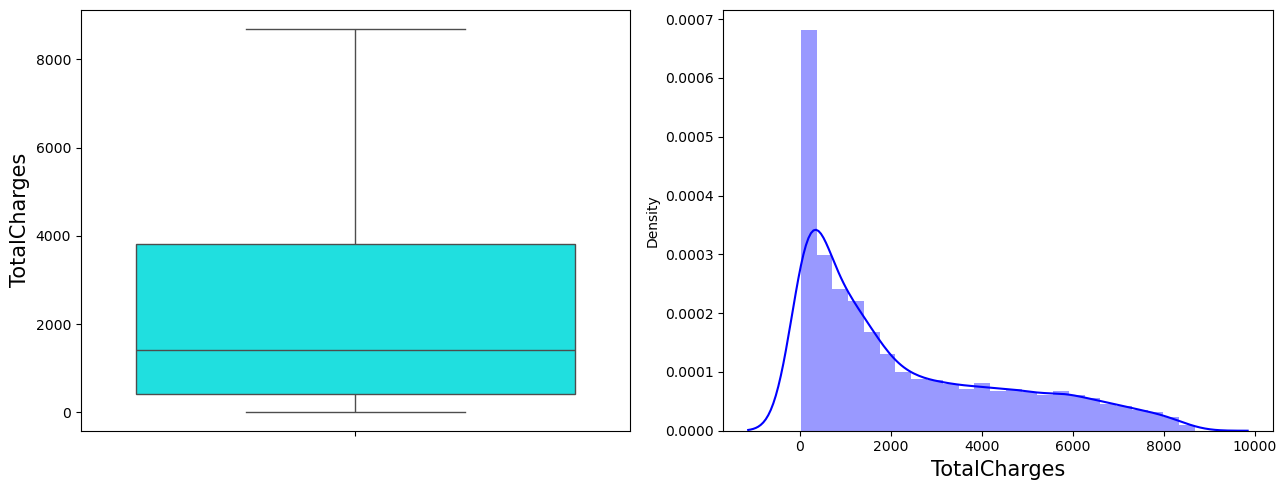

In [ ]:
plt.figure(figsize=(13,5))
plt.subplot(1,2,1)
sns.boxplot(y="TotalCharges",data=df,color="cyan")
plt.ylabel("TotalCharges",fontsize=15)
plt.subplot(1,2,2)
sns.distplot(df["TotalCharges"],color="b")
plt.xlabel("TotalCharges",fontsize=15)
plt.tight_layout()
plt.show()

In [ ]:
print("Mean of TotalCharges",df["TotalCharges"].mean())
print("Median of TotalCharges",df["TotalCharges"].median())

Mean of TotalCharges 2290.3533880171185
Median of TotalCharges 1403.875


# Observation
### We can see that Outliers doesnot exist, so no mean sensitivity issue present here.
### Distribution plot shows that Total charges feature is right skewed.
### Mean is greater than Median

In [ ]:
# Imputation of Missing value with mean
df["TotalCharges"]=df["TotalCharges"].fillna(df["TotalCharges"].mean())

In [ ]:
# Start with Enlisting Value counts & Sub-categories of different categorial features available
numerical=df.select_dtypes(exclude="object")
categorical=df.select_dtypes(include="object")

In [ ]:
for i in categorical:
    print(i)
    print(df[i].value_counts())
    print("-"*100)

gender
gender
Male      3541
Female    3480
Name: count, dtype: int64
----------------------------------------------------------------------------------------------------
Partner
Partner
No     3619
Yes    3402
Name: count, dtype: int64
----------------------------------------------------------------------------------------------------
Dependents
Dependents
No     4911
Yes    2110
Name: count, dtype: int64
----------------------------------------------------------------------------------------------------
PhoneService
PhoneService
Yes    6339
No      682
Name: count, dtype: int64
----------------------------------------------------------------------------------------------------
MultipleLines
MultipleLines
No                  3368
Yes                 2971
No phone service     682
Name: count, dtype: int64
----------------------------------------------------------------------------------------------------
InternetService
InternetService
Fiber optic    3090
DSL            2419
No        

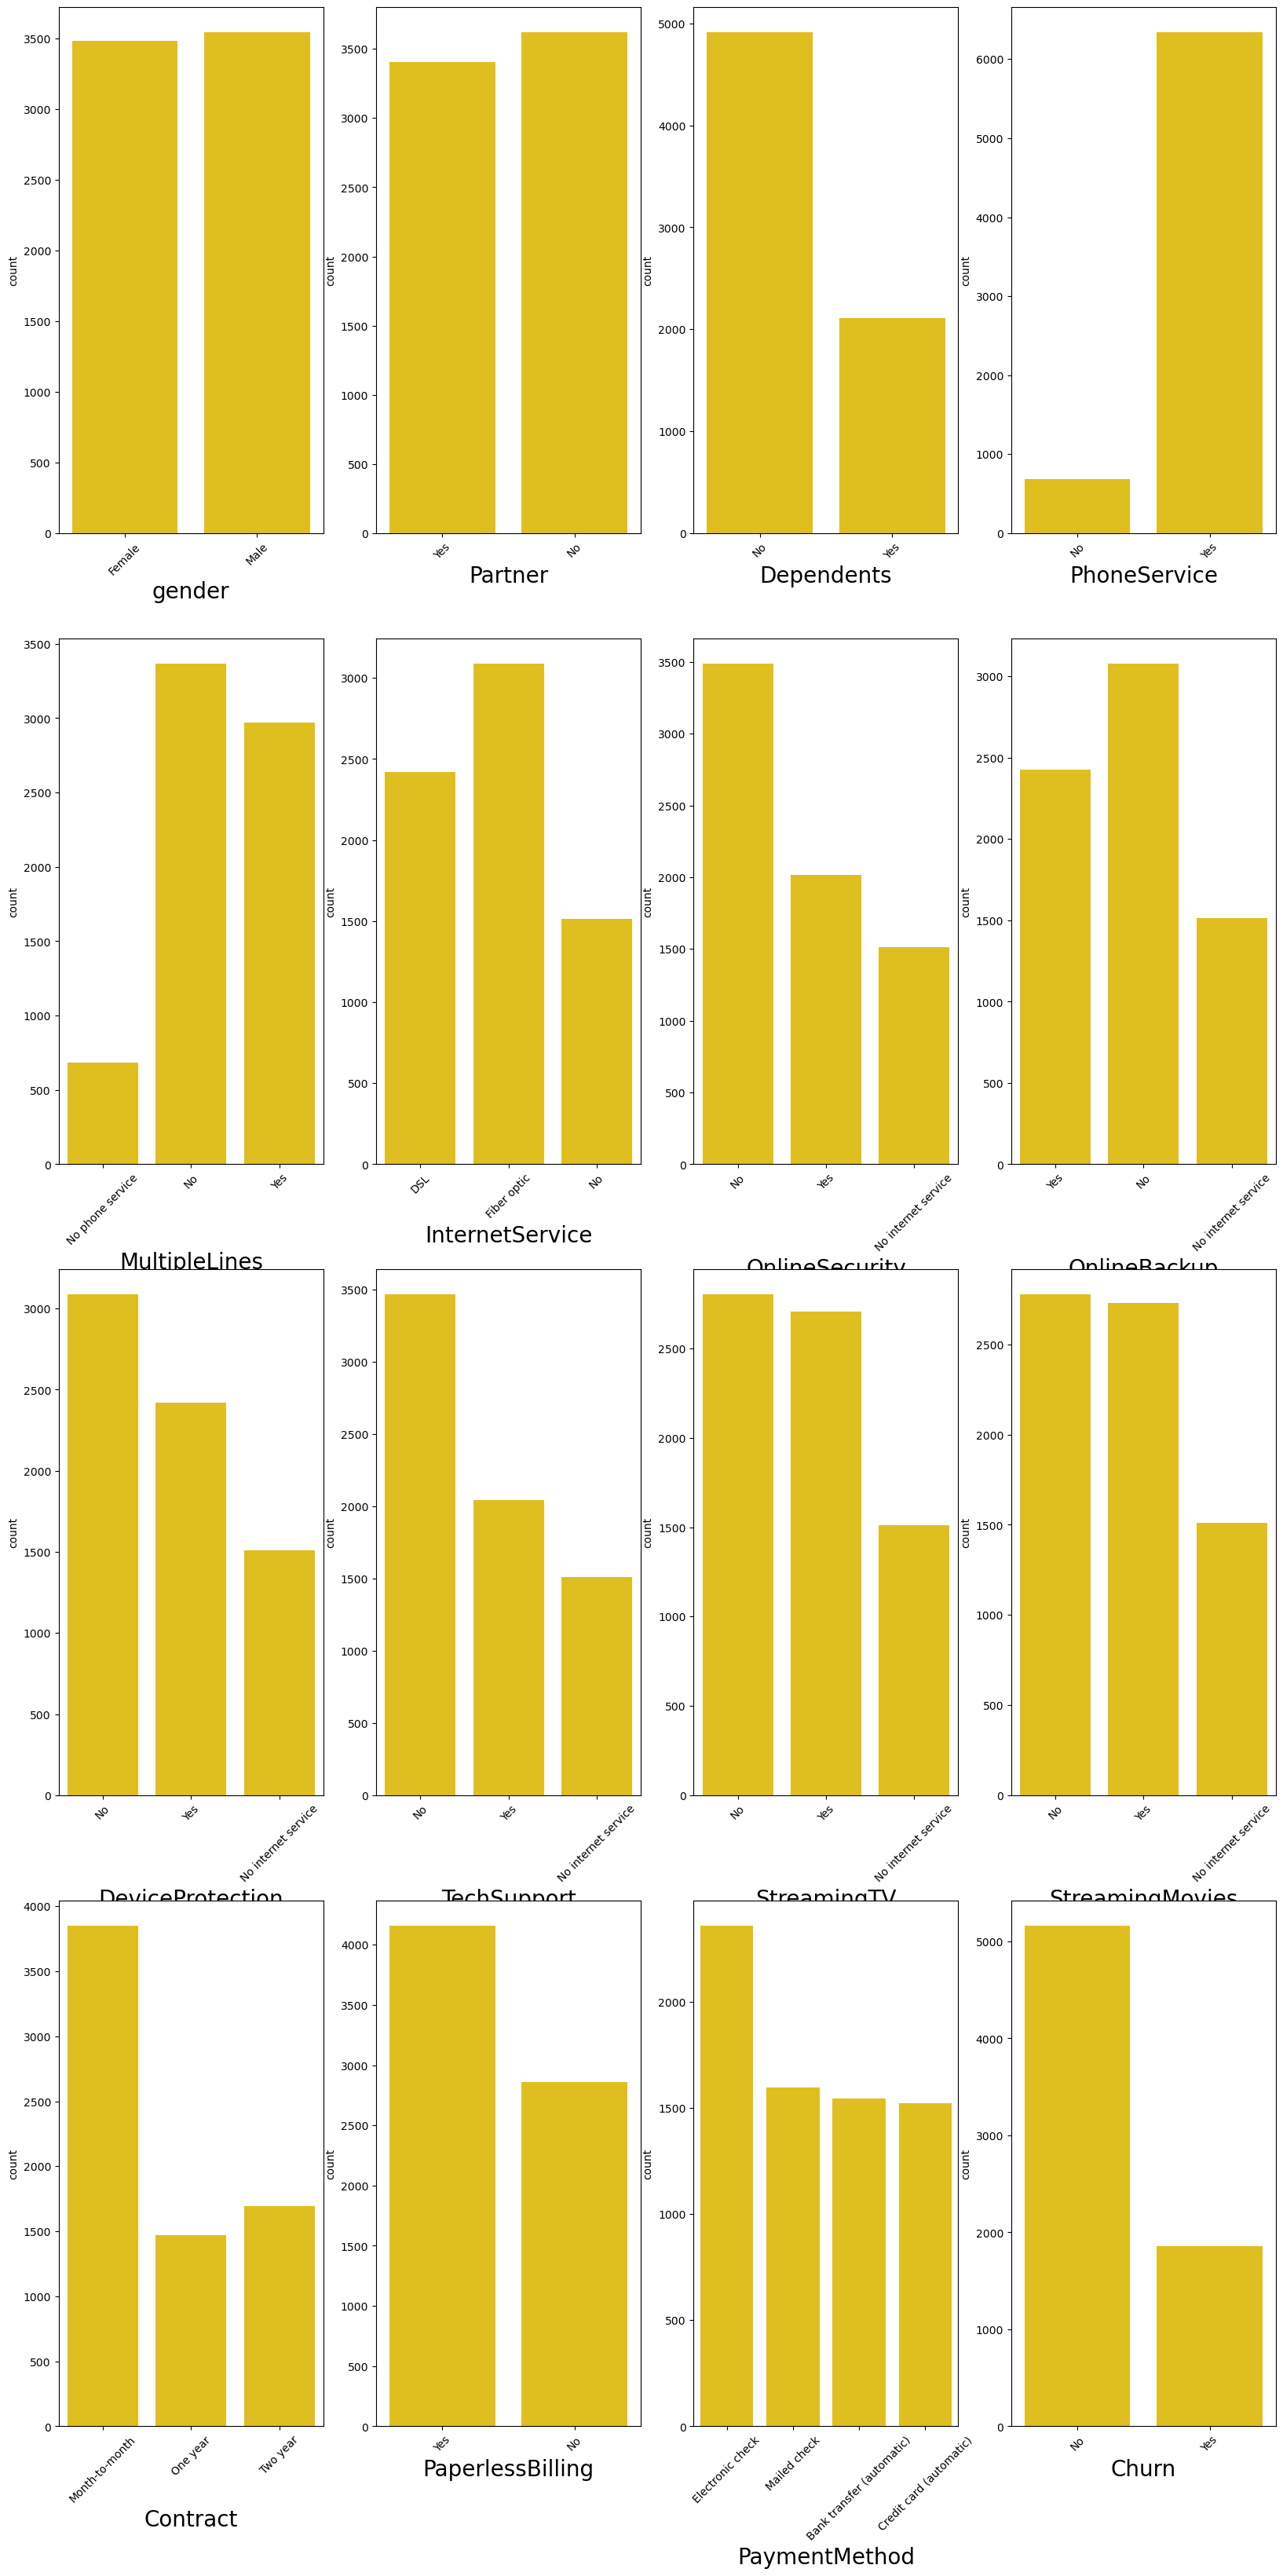

In [ ]:
sns.set_palette("hsv")
plt.figure(figsize=(20,40),facecolor="white")
plotnumber=1
for i in categorical:
    if plotnumber<=16:
        ax=plt.subplot(4,4,plotnumber)
        sns.countplot(x=df[i])
        plt.xlabel(i,fontsize=20)
        plt.xticks(rotation=45)
    plotnumber=plotnumber+1
plt.show()

# Target Variable Churn

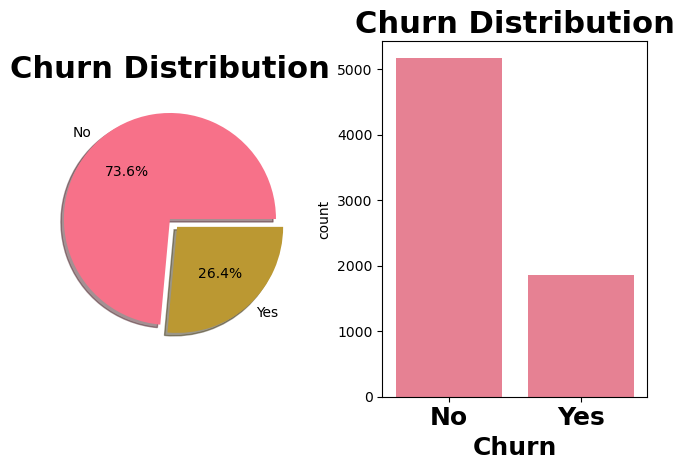

In [ ]:
sns.set_palette("husl")
plt.subplot(1,2,1)
df["Churn"].value_counts().plot.pie(explode=[0,0.1],autopct="%3.1f%%",shadow=True)
plt.title("Churn Distribution",fontsize=22,fontweight="bold")
plt.ylabel("")
plt.subplot(1,2,2)
sns.countplot(x="Churn",data=df)
plt.title("Churn Distribution",fontsize=22,fontweight="bold")
plt.xlabel("Churn",fontsize=18,fontweight="bold")
plt.xticks(fontsize=18,fontweight="bold")
plt.tight_layout()
plt.show()

# Gender vs Churn

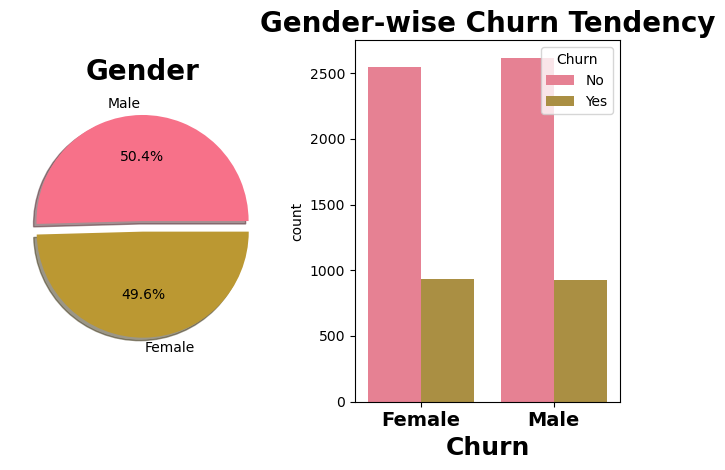

In [ ]:
sns.set_palette("husl")
plt.subplot(1,2,1)
df["gender"].value_counts().plot.pie(explode=[0,0.1],autopct="%2.1f%%",shadow=True)
plt.title("Gender",fontsize=20,fontweight="bold")
plt.ylabel("")
plt.subplot(1,2,2)
sns.countplot(x="gender",hue="Churn",data=df)
plt.title("Gender-wise Churn Tendency",fontsize=20,fontweight="bold")
plt.xlabel("Churn",fontsize=18,fontweight="bold")
plt.xticks(fontsize=14,fontweight="bold")
plt.tight_layout()
plt.show()

# lets see how many of them are Senior Citizen and Churn tendency in senior citizen

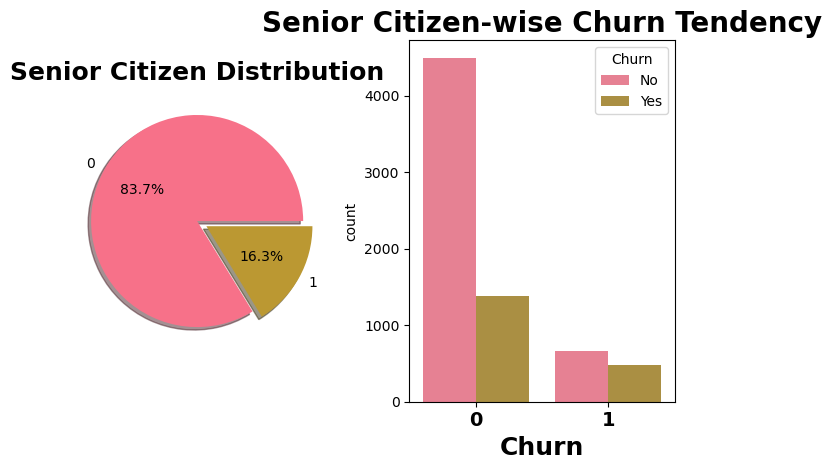

In [ ]:
sns.set_palette("husl")
plt.subplot(1,2,1)
df["SeniorCitizen"].value_counts().plot.pie(explode=[0,0.1],autopct="%2.1f%%",shadow=True)
plt.title("Senior Citizen Distribution",fontsize=18,fontweight="bold")
plt.ylabel("")
plt.subplot(1,2,2)
sns.countplot(x="SeniorCitizen",hue="Churn",data=df)
plt.title("Senior Citizen-wise Churn Tendency",fontsize=20,fontweight="bold")
plt.xlabel("Churn",fontsize=18,fontweight="bold")
plt.xticks(fontsize=14,fontweight="bold")
plt.tight_layout()
plt.show()

# Effect of Partner and Dependent on Churn

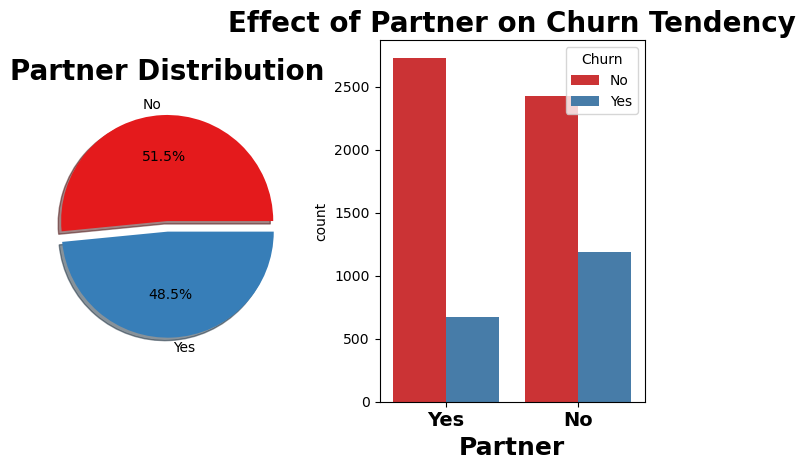

In [ ]:
sns.set_palette("Set1")
plt.subplot(1,2,1)
df["Partner"].value_counts().plot.pie(explode=[0,0.1],autopct="%2.1f%%",shadow=True)
plt.title("Partner Distribution",fontsize=20,fontweight="bold")
plt.ylabel("")
plt.subplot(1,2,2)
sns.countplot(x="Partner",hue="Churn",data=df)
plt.title("Effect of Partner on Churn Tendency",fontsize=20,fontweight="bold")
plt.xlabel("Partner",fontsize=18,fontweight="bold")
plt.xticks(fontsize=14,fontweight="bold")
plt.tight_layout()
plt.show()

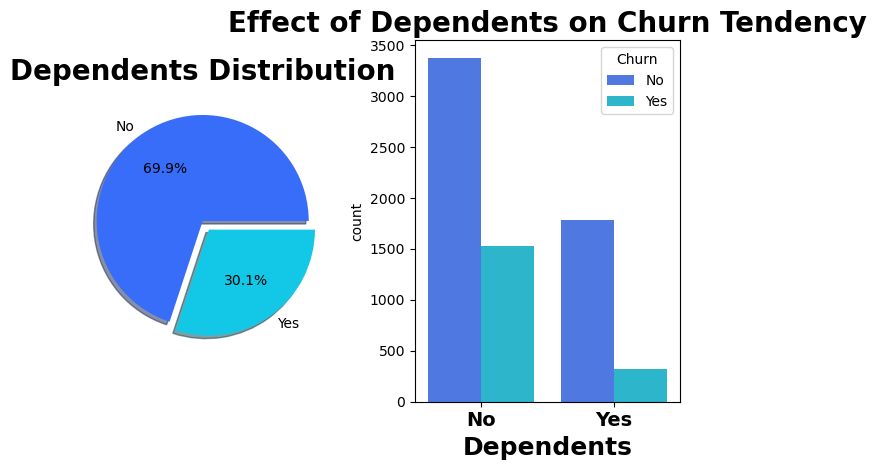

In [ ]:
sns.set_palette("rainbow")
plt.subplot(1,2,1)
df["Dependents"].value_counts().plot.pie(explode=[0,0.1],autopct="%2.1f%%",shadow=True)
plt.title("Dependents Distribution",fontsize=20,fontweight="bold")
plt.ylabel("")
plt.subplot(1,2,2)
sns.countplot(x="Dependents",hue="Churn",data=df)
plt.title("Effect of Dependents on Churn Tendency",fontsize=20,fontweight="bold")
plt.xlabel("Dependents",fontsize=18,fontweight="bold")
plt.xticks(fontsize=14,fontweight="bold")
plt.tight_layout()
plt.show()

# Using Label Encoder on Categorical variable

In [ ]:
le=LabelEncoder()
for i in categorical:
    df[i]=le.fit_transform(df[i])
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,1


# Outlier Detection and Removal

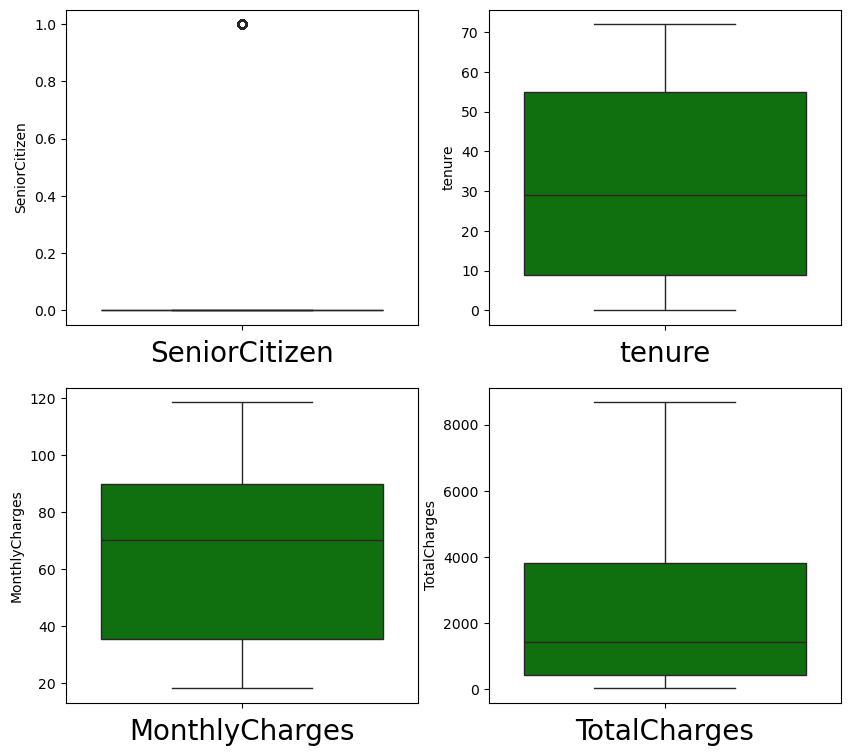

In [ ]:
plt.figure(figsize=(10,9),facecolor="white")
plotnumber=1

for column in numerical:
    if plotnumber<=4:
        ax=plt.subplot(2,2,plotnumber)
        sns.boxplot(df[column],color="g")
        plt.xlabel(column,fontsize=20)
    plotnumber+=1
plt.show()

# Outlier removal using zscore method

In [ ]:
z=np.abs(zscore(df))
df1=df[(z<3).all(axis=1)]

In [ ]:
df.shape

(7021, 20)

In [ ]:
df1.shape

(6339, 20)

In [ ]:
df=df1.copy()

In [ ]:
df.drop(["PhoneService"],axis=1,inplace=True)

# Checking Skewness in the dataset

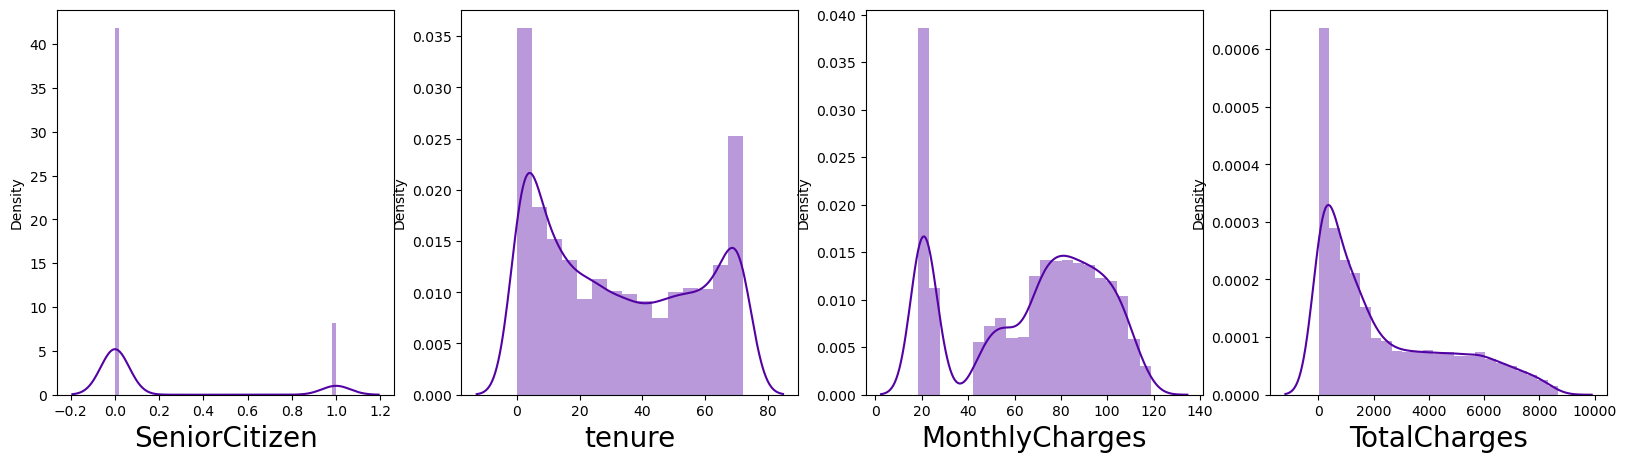

In [ ]:
plt.figure(figsize=(20,5),facecolor="white")
sns.set_palette("plasma")
plotnum=1
for col in numerical:
    if plotnum<=4:
        plt.subplot(1,4,plotnum)
        sns.distplot(df[col])
        plt.xlabel(col,fontsize=20)
    plotnum+=1
plt.show()

## There is no relevance of skewness for discrete numerical features like month and categorical feature. So we gone ignore skewness in discrete numerical and categorical feature.

In [ ]:
df.skew()

gender             -0.012939
SeniorCitizen       1.819335
Partner             0.049562
Dependents          0.871194
tenure              0.233517
MultipleLines       0.125532
InternetService     0.051965
OnlineSecurity      0.421216
OnlineBackup        0.166121
DeviceProtection    0.181524
TechSupport         0.408970
StreamingTV        -0.005185
StreamingMovies    -0.012505
Contract            0.624212
PaperlessBilling   -0.388673
PaymentMethod      -0.165613
MonthlyCharges     -0.404120
TotalCharges        0.895850
Churn               1.058644
dtype: float64

In [ ]:
skew=["TotalCharges"]
skewness=PowerTransformer(method="yeo-johnson")
df[skew]=skewness.fit_transform(df[skew].values)

In [ ]:
df.skew()

gender             -0.012939
SeniorCitizen       1.819335
Partner             0.049562
Dependents          0.871194
tenure              0.233517
MultipleLines       0.125532
InternetService     0.051965
OnlineSecurity      0.421216
OnlineBackup        0.166121
DeviceProtection    0.181524
TechSupport         0.408970
StreamingTV        -0.005185
StreamingMovies    -0.012505
Contract            0.624212
PaperlessBilling   -0.388673
PaymentMethod      -0.165613
MonthlyCharges     -0.404120
TotalCharges       -0.147794
Churn               1.058644
dtype: float64

# Balancing imbalanced target feature

In [ ]:
df["Churn"].value_counts()

Churn
0    4652
1    1687
Name: count, dtype: int64

# Balancing using SMOTE

In [ ]:
# splitting data in target and dependent feature
X=df.drop(["Churn"],axis=1)
y=df["Churn"]

In [ ]:
# Oversampling using SMOTE Techniques
from imblearn.over_sampling import SMOTE
oversample=SMOTE()
X,y=oversample.fit_resample(X,y)

# Standard Scalling

In [ ]:
sc=StandardScaler()
X_sc=sc.fit_transform(X)

# Machine Learning Model Building

## Finding best Random State

In [ ]:
maxAccu=0
masRS=0
for i in range(1,250):
    X_train,X_test,y_train,y_test=train_test_split(X_sc,y,test_size=0.3,random_state=i)
    dtc=DecisionTreeClassifier()
    dtc.fit(X_train,y_train)
    y_pred=dtc.predict(X_test)
    acc=accuracy_score(y_test,y_pred)
    if acc>maxAccu:
        maxAccu=acc
        maxRS=1
print("Best accuracy is",maxAccu,"on random_state",maxRS)

Best accuracy is 0.8065902578796562 on random_state 1


In [ ]:
maxAccu=0
masRS=0
for i in range(1,250):
    X_train,X_test,y_train,y_test=train_test_split(X_sc,y,test_size=0.3,random_state=i)
    lr=LogisticRegression()
    lr.fit(X_train,y_train)
    y_pred=lr.predict(X_test)
    acc=accuracy_score(y_test,y_pred)
    if acc>maxAccu:
        maxAccu=acc
        maxRS=1
print("Best accuracy is",maxAccu,"on random_state",maxRS)

Best accuracy is 0.8083810888252149 on random_state 1


In [ ]:
maxAccu=0
masRS=0
for i in range(1,250):
    X_train,X_test,y_train,y_test=train_test_split(X_sc,y,test_size=0.3,random_state=i)
    rfc=RandomForestClassifier()
    rfc.fit(X_train,y_train)
    y_pred=rfc.predict(X_test)
    acc=accuracy_score(y_test,y_pred)
    if acc>maxAccu:
        maxAccu=acc
        maxRS=1
print("Best accuracy is",maxAccu,"on random_state",maxRS)

Best accuracy is 0.8635386819484241 on random_state 1


In [ ]:
X_train,X_test,y_train,y_test=train_test_split(X_sc,y,test_size=0.3,random_state=1)
lr=LogisticRegression()
lr.fit(X_train,y_train)
y_pred=lr.predict(X_test)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.81      0.74      0.77      1409
           1       0.76      0.83      0.79      1383

    accuracy                           0.78      2792
   macro avg       0.78      0.78      0.78      2792
weighted avg       0.78      0.78      0.78      2792



In [ ]:
X_train,X_test,y_train,y_test=train_test_split(X_sc,y,test_size=0.3,random_state=1)
rfc=RandomForestClassifier()
rfc.fit(X_train,y_train)
y_pred=rfc.predict(X_test)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.86      0.82      0.84      1409
           1       0.82      0.86      0.84      1383

    accuracy                           0.84      2792
   macro avg       0.84      0.84      0.84      2792
weighted avg       0.84      0.84      0.84      2792



In [ ]:
X_train,X_test,y_train,y_test=train_test_split(X_sc,y,test_size=0.3,random_state=1)
dtc=DecisionTreeClassifier()
dtc.fit(X_train,y_train)
y_pred=dtc.predict(X_test)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.80      0.78      0.79      1409
           1       0.78      0.80      0.79      1383

    accuracy                           0.79      2792
   macro avg       0.79      0.79      0.79      2792
weighted avg       0.79      0.79      0.79      2792



# Finding Best parameters for our dataset

In [ ]:
param_grid={
    "criterion":["gini","entropy"],
    "max_depth":[i for i in range(1,10,2)],
    "min_samples_split":[i for i in range(1,20,3)],
    "min_samples_leaf":[i for i in range(1,10)]}

grid_search=GridSearchCV(dtc,param_grid,cv=5)
grid_search.fit(X_train,y_train)
print("Best params",grid_search.best_params_)

Best params {'criterion': 'gini', 'max_depth': 9, 'min_samples_leaf': 6, 'min_samples_split': 19}


# Final Model

In [ ]:
final_mod=DecisionTreeClassifier(criterion='entropy', max_depth= 9,min_samples_leaf= 9,min_samples_split= 7)
final_mod.fit(X_train,y_train)
y_pred=final_mod.predict(X_test)
print("Accuracy Score :\n",accuracy_score(y_test,y_pred))

Accuracy Score :
 0.7793696275071633
